In [ ]:
import pandas as pd

In [ ]:
df=pd.read_csv("/content/costProfCat-VienPOI-all.csv", sep=';')
df

,from,to,cost,profit,category
0,1,2,740.592.073.561.656,1478,Zoo
1,1,3,719.161.300.154.117,1243,Entertainment
2,1,4,470.482.001.718.146,1042,Museum
3,1,5,465.753.807.495.913,1750,Palace
4,1,6,42.511.484.871.629,1581,Museum
...,...,...,...,...,...
751,29,24,823.844.039.936.781,572,Park
752,29,25,536.041.255.465.363,1042,Historical
753,29,26,492.536.147.308.187,860,Historical
754,29,27,603.526.020.847.893,453,Cultural


In [ ]:
import pandas as pd

category_mapping = {
    7: "Palace", 5: "Palace", 1: "Palace",
    10: "Zoo", 2: "Zoo",
    15: "Entertainment", 3: "Entertainment",
    28: "Museum", 22: "Museum", 21: "Museum", 19: "Museum",
    16: "Museum", 14: "Museum", 13: "Museum", 11: "Museum",
    9: "Museum", 6: "Museum", 4: "Museum",
    8: "Structure",
    26: "History", 25: "History", 23: "History", 20: "History",
    18: "History", 17: "History",
    29: "Park", 24: "Park",
    27: "Cultural"
}

df['from'] = df['from'].replace(category_mapping)
df['to'] = df['to'].replace(category_mapping)

df

,from,to,cost,profit,category
0,Palace,Zoo,740.592.073.561.656,1478,Zoo
1,Palace,Entertainment,719.161.300.154.117,1243,Entertainment
2,Palace,Museum,470.482.001.718.146,1042,Museum
3,Palace,Palace,465.753.807.495.913,1750,Palace
4,Palace,Museum,42.511.484.871.629,1581,Museum
...,...,...,...,...,...
751,Park,Park,823.844.039.936.781,572,Park
752,Park,History,536.041.255.465.363,1042,Historical
753,Park,History,492.536.147.308.187,860,Historical
754,Park,Cultural,603.526.020.847.893,453,Cultural


In [ ]:
df=df.drop(columns=["category"])
df

,from,to,cost,profit
0,Palace,Zoo,740.592.073.561.656,1478
1,Palace,Entertainment,719.161.300.154.117,1243
2,Palace,Museum,470.482.001.718.146,1042
3,Palace,Palace,465.753.807.495.913,1750
4,Palace,Museum,42.511.484.871.629,1581
...,...,...,...,...
751,Park,Park,823.844.039.936.781,572
752,Park,History,536.041.255.465.363,1042
753,Park,History,492.536.147.308.187,860
754,Park,Cultural,603.526.020.847.893,453


In [ ]:
df.rename(columns={
    "from": "Lokasi_Awal",
    "to": "Lokasi_Tujuan",
    "cost": "Jarak (meter)",
    "profit": "Jumlah_Pengunjung"
}, inplace=True)
df

,Lokasi_Awal,Lokasi_Tujuan,Jarak (meter),Jumlah_Pengunjung
0,Palace,Zoo,740.592.073.561.656,1478
1,Palace,Entertainment,719.161.300.154.117,1243
2,Palace,Museum,470.482.001.718.146,1042
3,Palace,Palace,465.753.807.495.913,1750
4,Palace,Museum,42.511.484.871.629,1581
...,...,...,...,...
751,Park,Park,823.844.039.936.781,572
752,Park,History,536.041.255.465.363,1042
753,Park,History,492.536.147.308.187,860
754,Park,Cultural,603.526.020.847.893,453


In [ ]:
df['Jarak (meter)'] = df['Jarak (meter)'].astype(str).str.replace('.', '', regex=False)

df['Jarak (meter)'] = pd.to_numeric(df['Jarak (meter)'], errors='coerce')

df


,Lokasi_Awal,Lokasi_Tujuan,Jarak (meter),Jumlah_Pengunjung
0,Palace,Zoo,740592073561656,1478
1,Palace,Entertainment,719161300154117,1243
2,Palace,Museum,470482001718146,1042
3,Palace,Palace,465753807495913,1750
4,Palace,Museum,42511484871629,1581
...,...,...,...,...
751,Park,Park,823844039936781,572
752,Park,History,536041255465363,1042
753,Park,History,492536147308187,860
754,Park,Cultural,603526020847893,453


In [ ]:
data = df['Jarak (meter)'].values

scaling_factor = 10**12 

df['Jarak'] = (data / scaling_factor).round(2)
df

,Lokasi_Awal,Lokasi_Tujuan,Jarak (meter),Jumlah_Pengunjung,Jarak
0,Palace,Zoo,740592073561656,1478,740.59
1,Palace,Entertainment,719161300154117,1243,719.16
2,Palace,Museum,470482001718146,1042,470.48
3,Palace,Palace,465753807495913,1750,465.75
4,Palace,Museum,42511484871629,1581,42.51
...,...,...,...,...,...
751,Park,Park,823844039936781,572,823.84
752,Park,History,536041255465363,1042,536.04
753,Park,History,492536147308187,860,492.54
754,Park,Cultural,603526020847893,453,603.53


In [ ]:
df = df[df["Lokasi_Awal"] != df["Lokasi_Tujuan"]]
df

,Lokasi_Awal,Lokasi_Tujuan,Jarak (meter),Jumlah_Pengunjung,Jarak
0,Palace,Zoo,740592073561656,1478,740.59
1,Palace,Entertainment,719161300154117,1243,719.16
2,Palace,Museum,470482001718146,1042,470.48
4,Palace,Museum,42511484871629,1581,42.51
6,Palace,Structure,959387904442545,571,959.39
...,...,...,...,...,...
750,Park,History,534934493758418,1056,534.93
752,Park,History,536041255465363,1042,536.04
753,Park,History,492536147308187,860,492.54
754,Park,Cultural,603526020847893,453,603.53


In [ ]:
df.isnull().sum()

,0
Lokasi_Awal,0
Lokasi_Tujuan,0
Jarak (meter),0
Jumlah_Pengunjung,0
Jarak,0


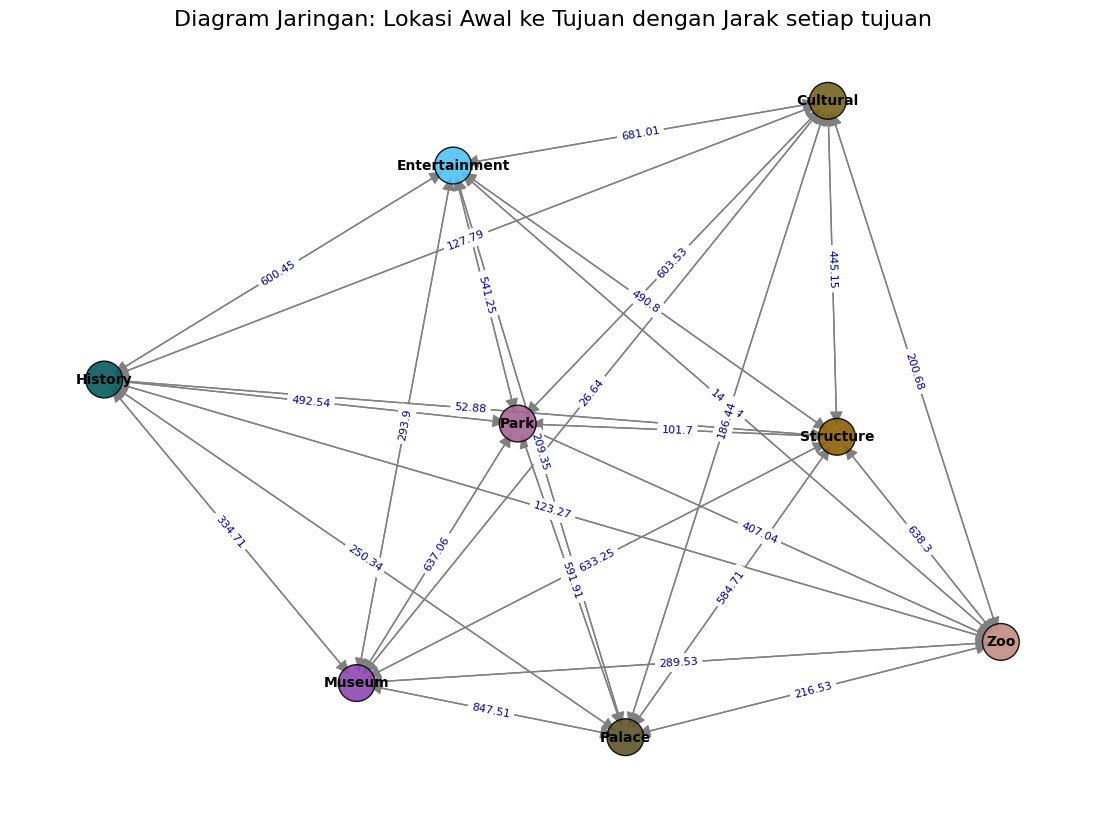

In [ ]:
import networkx as nx
import matplotlib.pyplot as plt
import random

G = nx.DiGraph()

for _, row in df.iterrows():
    G.add_edge(row["Lokasi_Awal"], row["Lokasi_Tujuan"], weight=row["Jarak"])

pos = nx.spring_layout(G, seed=42) 

node_colors = {node: f'#{random.randint(0, 0xFFFFFF):06x}' for node in G.nodes()}

plt.figure(figsize=(14, 10))

nx.draw_networkx_nodes(
    G, pos, node_size=700, node_color=[node_colors[node] for node in G.nodes()],
    edgecolors="black", alpha=0.9
)

nx.draw_networkx_edges(
    G, pos, edge_color="gray", arrowsize=20, arrowstyle="-|>"
)

labels = {}
for node in G.nodes():
    labels[node] = f"{node}" if node in df["Lokasi_Tujuan"].values else node
nx.draw_networkx_labels(
    G, pos, labels=labels, font_size=10, font_color="black", font_weight="bold"
)

edge_labels = nx.get_edge_attributes(G, "weight")
nx.draw_networkx_edge_labels(
    G, pos, edge_labels=edge_labels, font_size=8, font_color="darkblue"
)

plt.title("Diagram Jaringan: Lokasi Awal ke Tujuan dengan Jarak setiap tujuan", fontsize=16)
plt.axis("off")
plt.show()


In [ ]:
weights = [d['weight'] for _, _, d in G.edges(data=True)]

min_distance = min(weights)
max_distance = max(weights)

print(f"Jarak terkecil berada pada rentang: {min_distance}")
print(f"Jarak terbesar berada pada rentang: {max_distance}")


Jarak terkecil berada pada rentang: 26.64
Jarak terbesar berada pada rentang: 847.51


   Lokasi_Tujuan  Jumlah_Pengunjung
2        History             246730
3         Museum             217702
4         Palace              92200
1  Entertainment              85098
7            Zoo              47580
5           Park              18044
6      Structure              15417
0       Cultural              12231


<ipython-input-12-3387b55c28fa>:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=total_pengunjung_tujuan, x="Lokasi_Tujuan", y="Jumlah_Pengunjung", palette="viridis")


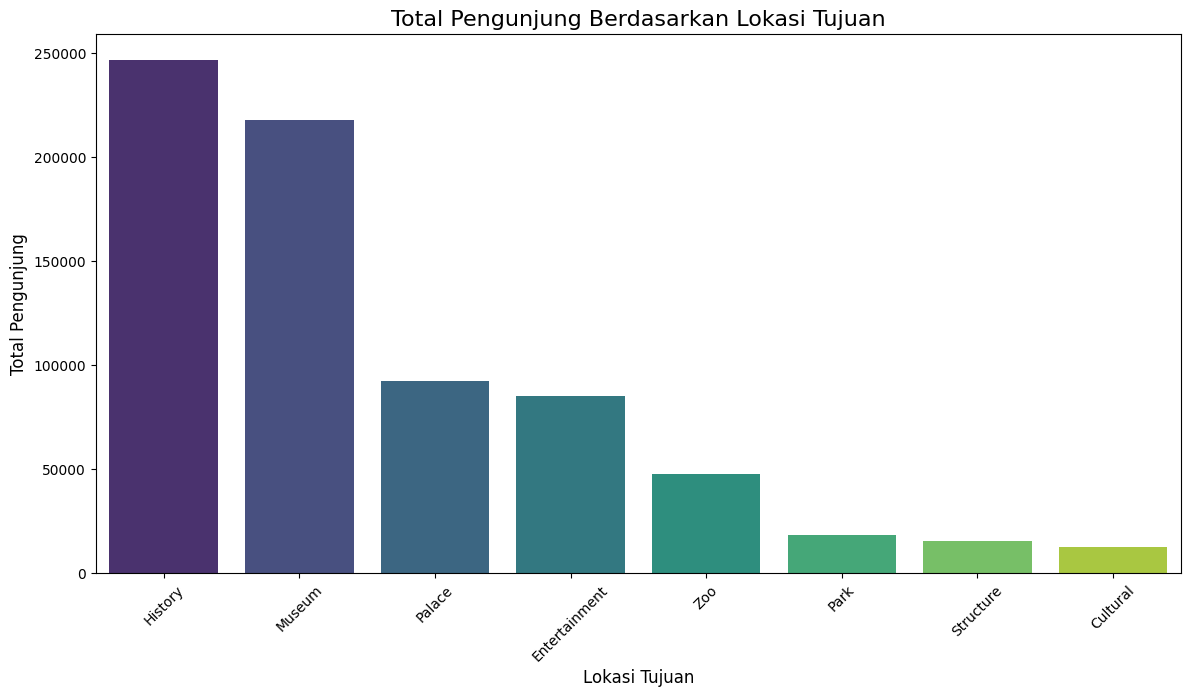

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

total_pengunjung_tujuan = df.groupby("Lokasi_Tujuan")["Jumlah_Pengunjung"].sum().reset_index()

total_pengunjung_tujuan = total_pengunjung_tujuan.sort_values(by="Jumlah_Pengunjung", ascending=False)
print(total_pengunjung_tujuan)
plt.figure(figsize=(14, 7))
sns.barplot(data=total_pengunjung_tujuan, x="Lokasi_Tujuan", y="Jumlah_Pengunjung", palette="viridis")
plt.title("Total Pengunjung Berdasarkan Lokasi Tujuan", fontsize=16)
plt.xlabel("Lokasi Tujuan", fontsize=12)
plt.ylabel("Total Pengunjung", fontsize=12)
plt.xticks(rotation=45)
plt.show()



Lokasi_Tujuan  Cultural  Entertainment  History  Museum  Palace  Park  \
Lokasi_Awal                                                             
Cultural              0           3273    11215   12806    3688   694   
Entertainment       906              0    22430   25612    7376  1388   
History            2718          19638        0   76836   22128  4164   
Museum             4983          36003   123365       0   40568  7634   
Palace             1359           9819    33645   38418       0  2082   
Park                906           6546    22430   25612    7376     0   
Structure           453           3273    11215   12806    3688   694   
Zoo                 906           6546    22430   25612    7376  1388   

Lokasi_Tujuan  Structure    Zoo  
Lokasi_Awal                      
Cultural             571   1830  
Entertainment       1142   3660  
History             3426  10980  
Museum              6281  20130  
Palace              1713   5490  
Park                1142   3660

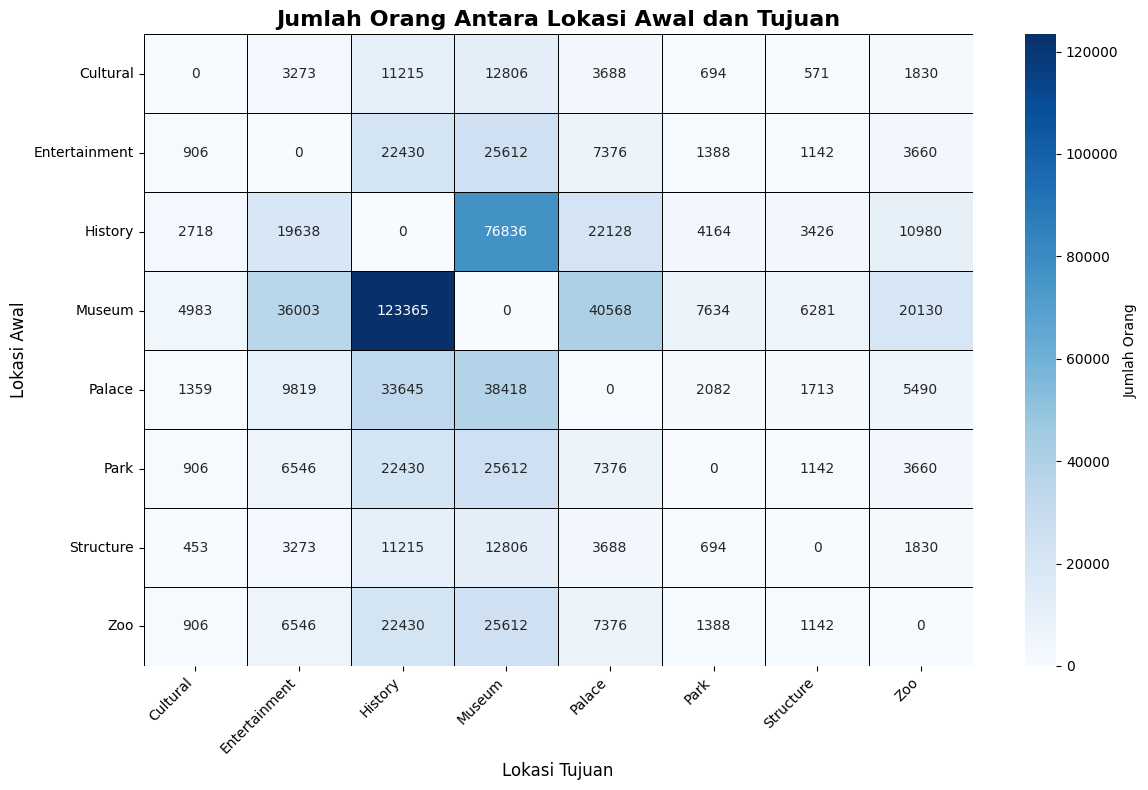

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

pivot_table = df.pivot_table(
    index="Lokasi_Awal",
    columns="Lokasi_Tujuan",
    values="Jumlah_Pengunjung",
    aggfunc="sum",
    fill_value=0
)

print(pivot_table)

plt.figure(figsize=(12, 8))
sns.heatmap(
    pivot_table,
    annot=True,
    fmt=".0f",
    cmap="Blues",
    linewidths=0.5,
    linecolor="black",
    cbar_kws={"label": "Jumlah Orang"}
)

plt.title("Jumlah Orang Antara Lokasi Awal dan Tujuan", fontsize=16, fontweight="bold")
plt.xlabel("Lokasi Tujuan", fontsize=12)
plt.ylabel("Lokasi Awal", fontsize=12)
plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)

plt.tight_layout()
plt.show()


In [ ]:
df.to_csv("df_setelah_preprocessing.csv", index = False)